In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [5]:
import os

os.listdir()

['.config', 'test.csv', 'train.csv', 'sample_data']

In [6]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [7]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (10003, 2)
Test shape: (3080, 2)


In [8]:
train_df.head()

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [9]:
test_df.head()

,text,category
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I order...",card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival


In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      10003 non-null  object
 1   category  10003 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [11]:
print("Train missing values:")
print(train_df.isnull().sum())

print("\nTest missing values:")
print(test_df.isnull().sum())

Train missing values:
text        0
category    0
dtype: int64

Test missing values:
text        0
category    0
dtype: int64


In [12]:
print("Train duplicates:", train_df.duplicated().sum())
print("Test duplicates:", test_df.duplicated().sum())

Train duplicates: 0
Test duplicates: 0


In [13]:
print("Number of intents:", train_df["category"].nunique())

Number of intents: 77


In [14]:
intent_counts = train_df["category"].value_counts()

print(intent_counts)

category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64


In [15]:
print("Number of intents:", intent_counts.shape[0])
print("Maximum samples:", intent_counts.max())
print("Minimum samples:", intent_counts.min())
print("Average samples:", intent_counts.mean())

Number of intents: 77
Maximum samples: 187
Minimum samples: 35
Average samples: 129.9090909090909


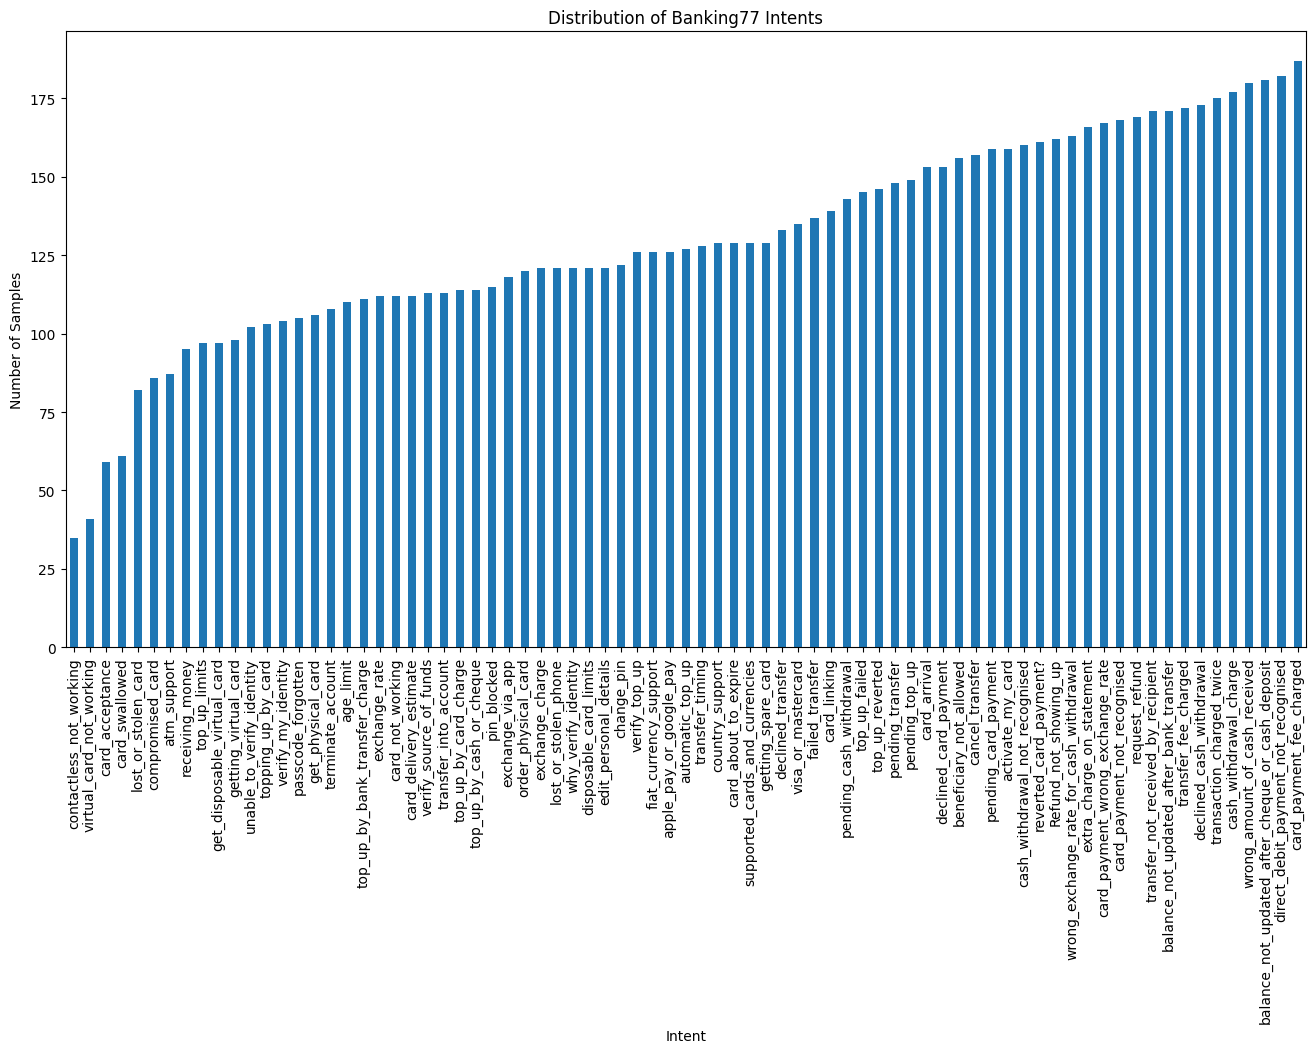

In [16]:
plt.figure(figsize=(16, 8))

intent_counts.sort_values().plot(kind="bar")

plt.title("Distribution of Banking77 Intents")
plt.xlabel("Intent")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)

plt.show()

In [17]:
train_df["text_length"] = train_df["text"].str.split().str.len()

print(train_df["text_length"].describe())

count    10003.000000
mean        11.949415
std          7.891577
min          2.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         79.000000
Name: text_length, dtype: float64


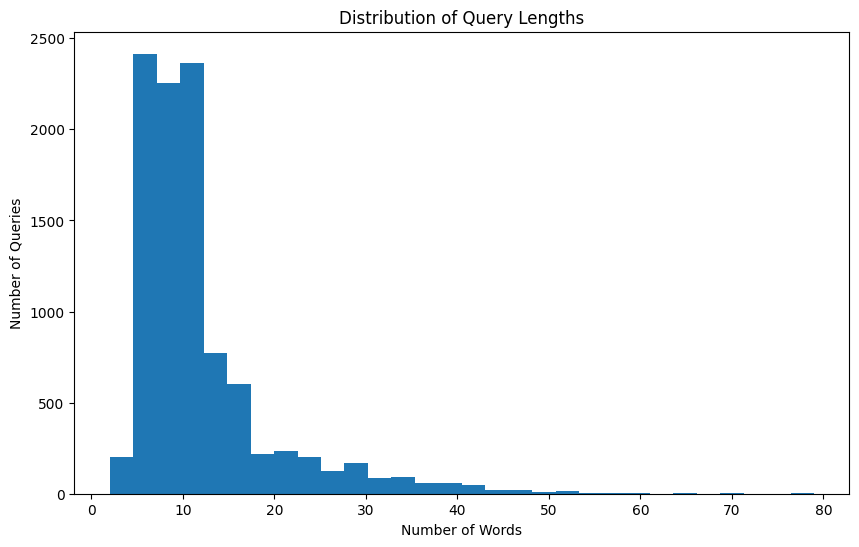

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(train_df["text_length"], bins=30)

plt.title("Distribution of Query Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Queries")

plt.show()

In [19]:
train_df.drop(columns=["text_length"], inplace=True)

In [20]:
text_counts = train_df["text"].value_counts()

print("Unique texts:", train_df["text"].nunique())
print("Total texts:", len(train_df))
print("Repeated texts:", (text_counts > 1).sum())

Unique texts: 10003
Total texts: 10003
Repeated texts: 0


In [21]:
repeated_texts = text_counts[text_counts > 1]

print(repeated_texts.head(10))

Series([], Name: count, dtype: int64)


In [22]:
X = train_df["text"]
y = train_df["category"]
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(test_df))

Training samples: 8002
Validation samples: 2001
Test samples: 3080


In [23]:
X_train.head(10)

,text
8665,How long do transfers take to show up in my ac...
9391,Why are fees charged for cash withdrawals? I w...
3048,where can i have a virtual card
7707,how do I find the code to verify the top up card?
7431,Why was I unable to finish this transfer?
7705,"I'm trying to verify my top-up card, but I can..."
4773,A debit came through that I need to dispute.
4441,How many disposable cards can I make in a day?
1894,Does it cost me anything to top up my account ...
5327,I have lost my phone.


In [24]:
X_train = X_train.str.lower().str.strip()
X_val = X_val.str.lower().str.strip()

In [25]:
print(X_train.head())

8665    how long do transfers take to show up in my ac...
9391    why are fees charged for cash withdrawals? i w...
3048                      where can i have a virtual card
7707    how do i find the code to verify the top up card?
7431            why was i unable to finish this transfer?
Name: text, dtype: object


In [26]:
print(X_train.shape)
print(X_val.shape)

(8002,)
(2001,)


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    ngram_range=(1, 2)
)

In [28]:
ngram_range=(1, 2)

In [29]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

In [30]:
print("Training shape:", X_train_tfidf.shape)
print("Validation shape:", X_val_tfidf.shape)

Training shape: (8002, 20886)
Validation shape: (2001, 20886)


In [31]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [32]:
y_pred_logistic = logistic_model.predict(X_val_tfidf)

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_val, y_pred_logistic))
print("Precision:", precision_score(y_val, y_pred_logistic, average="weighted"))
print("Recall:", recall_score(y_val, y_pred_logistic, average="weighted"))
print("F1-score:", f1_score(y_val, y_pred_logistic, average="weighted"))

Accuracy: 0.8430784607696152
Precision: 0.850158196483869
Recall: 0.8430784607696152
F1-score: 0.842180129754997


In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_val, y_pred_logistic))

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.97      0.91      0.94        32
                                activate_my_card       0.97      0.94      0.95        32
                                       age_limit       1.00      0.91      0.95        22
                         apple_pay_or_google_pay       0.96      0.96      0.96        25
                                     atm_support       0.78      0.82      0.80        17
                                automatic_top_up       1.00      0.84      0.91        25
         balance_not_updated_after_bank_transfer       0.76      0.76      0.76        34
balance_not_updated_after_cheque_or_cash_deposit       0.84      0.86      0.85        36
                         beneficiary_not_allowed       0.81      0.81      0.81        31
                                 cancel_transfer       0.88      0.94      0.91        31
         

In [35]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

LinearSVC()

In [36]:
y_pred_svm = svm_model.predict(X_val_tfidf)

In [37]:
print("Accuracy:", accuracy_score(y_val, y_pred_svm))
print("Precision:", precision_score(y_val, y_pred_svm, average="weighted"))
print("Recall:", recall_score(y_val, y_pred_svm, average="weighted"))
print("F1-score:", f1_score(y_val, y_pred_svm, average="weighted"))

Accuracy: 0.8830584707646177
Precision: 0.887923229610728
Recall: 0.8830584707646177
F1-score: 0.8834689506947535


In [38]:
print(classification_report(y_val, y_pred_svm))

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.94      0.91      0.92        32
                                activate_my_card       1.00      0.94      0.97        32
                                       age_limit       1.00      0.95      0.98        22
                         apple_pay_or_google_pay       1.00      0.96      0.98        25
                                     atm_support       0.88      0.82      0.85        17
                                automatic_top_up       1.00      0.92      0.96        25
         balance_not_updated_after_bank_transfer       0.82      0.79      0.81        34
balance_not_updated_after_cheque_or_cash_deposit       0.92      0.94      0.93        36
                         beneficiary_not_allowed       0.84      0.87      0.86        31
                                 cancel_transfer       1.00      0.97      0.98        31
         

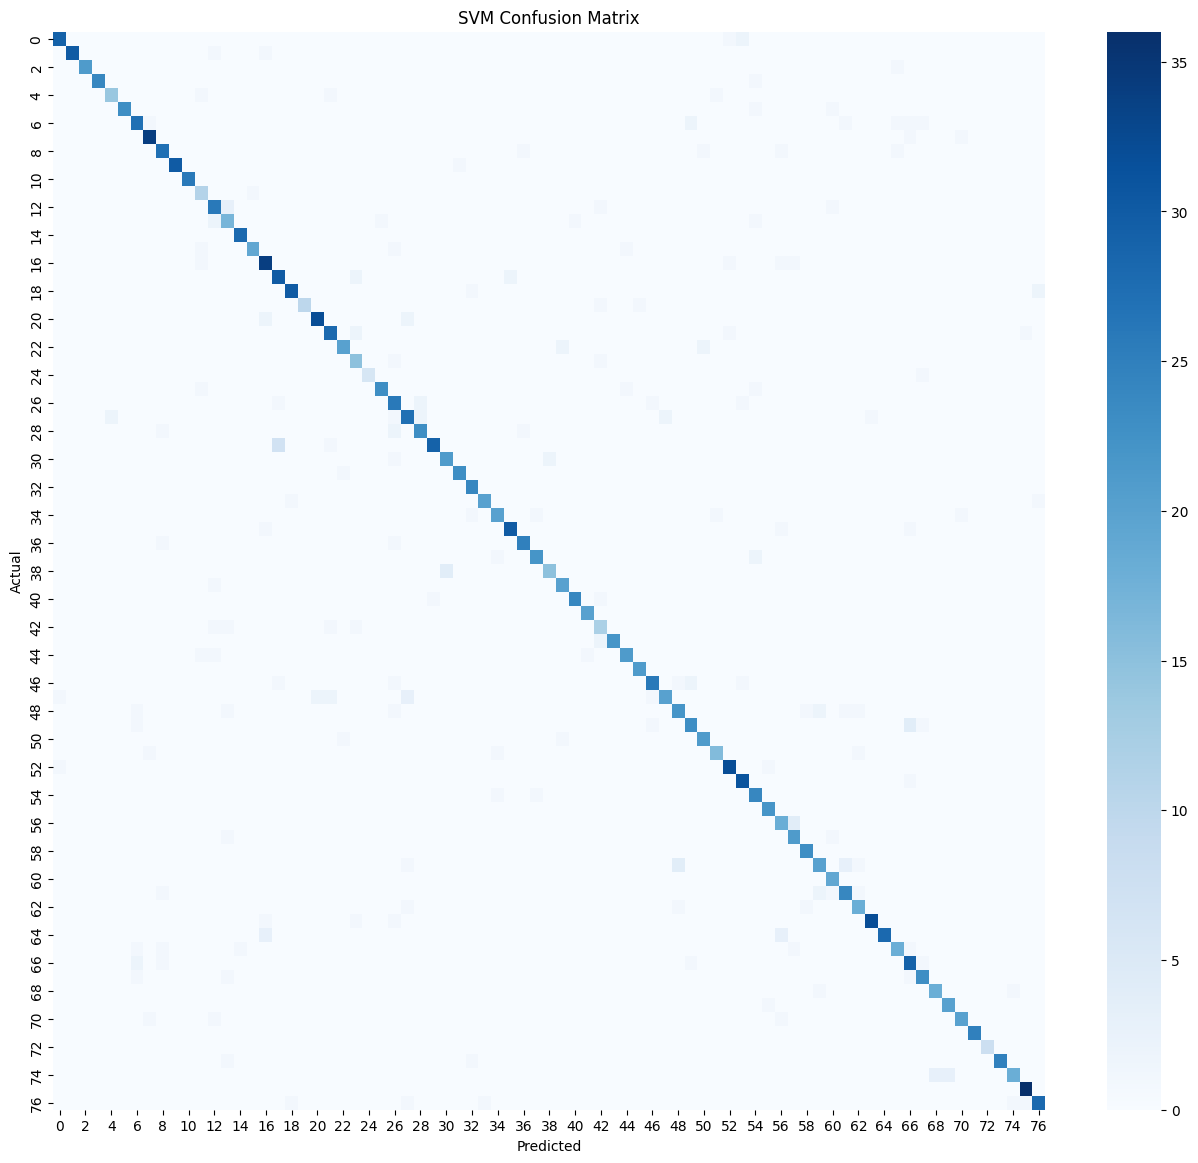

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_val, y_pred_svm)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, cmap="Blues")

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [40]:
cm = confusion_matrix(y_val, y_pred_svm)

errors = []

for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i, j] > 0:
            errors.append([
                cm[i, j],
                svm_model.classes_[i],
                svm_model.classes_[j]
            ])

errors = sorted(errors, reverse=True)

for error in errors[:15]:
    print(error)

[np.int64(7), 'direct_debit_payment_not_recognised', 'card_payment_not_recognised']
[np.int64(4), 'top_up_failed', 'pending_top_up']
[np.int64(4), 'top_up_by_bank_transfer_charge', 'top_up_by_card_charge']
[np.int64(4), 'pending_transfer', 'transfer_not_received_by_recipient']
[np.int64(4), 'get_disposable_virtual_card', 'disposable_card_limits']
[np.int64(3), 'why_verify_identity', 'verify_my_identity']
[np.int64(3), 'why_verify_identity', 'unable_to_verify_identity']
[np.int64(3), 'transfer_fee_charged', 'top_up_by_bank_transfer_charge']
[np.int64(3), 'transfer_fee_charged', 'card_payment_fee_charged']
[np.int64(3), 'top_up_failed', 'top_up_reverted']
[np.int64(3), 'pending_cash_withdrawal', 'declined_cash_withdrawal']
[np.int64(3), 'card_arrival', 'card_delivery_estimate']
[np.int64(2), 'transfer_not_received_by_recipient', 'balance_not_updated_after_bank_transfer']
[np.int64(2), 'top_up_reverted', 'top_up_failed']
[np.int64(2), 'pending_top_up', 'top_up_failed']


In [41]:
pair = (y_val == 'direct_debit_payment_not_recognised') & (y_pred_svm == 'card_payment_not_recognised')

print("Number of errors:", pair.sum())
print()

for text in X_val[pair]:
    print("-", text)

Number of errors: 7

- there is a payment showing on my app that i didn't do. will you please cancel this payment and refund my money ?
- there is a payment in my app that i did not make.  i have not used that card all day  please reimburse my money.
- my app is showing a payment that i know i did not do. can you please cancel that transaction and credit my account please?
- my accounts been charged a payment for something i didn't make.
- purchases i did not make are appearing in my bank statement?
- i would like to dispute a payment i didnt make
- what is this charge i didnt do it what can i do


In [42]:
pair = (y_val == 'top_up_failed') & (y_pred_svm == 'pending_top_up')

print("Number of errors:", pair.sum())
print()

for text in X_val[pair]:
    print("-", text)

Number of errors: 4

- i'm not sure if my pop-up went through.
- i'm confused as to why my top-up did not go through.
- i have the funds, why can i not use my top-up?
- my top-up hasn't gone through, what happened?


In [43]:
pair = (y_val == 'pending_transfer') & (y_pred_svm == 'transfer_not_received_by_recipient')

print("Number of errors:", pair.sum())
print()

for text in X_val[pair]:
    print("-", text)

Number of errors: 4

- will my transfer be done soon?
- i put in money for vacation and its not showing. i need that money today, how long will it take
- why is the transaction not posting?
- i sent payment with eu transfer and they still haven't received it. how long does it take?


In [44]:
tfidf2 = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf2 = tfidf2.fit_transform(X_train)
X_val_tfidf2 = tfidf2.transform(X_val)

svm_model2 = LinearSVC()
svm_model2.fit(X_train_tfidf2, y_train)

y_pred_svm2 = svm_model2.predict(X_val_tfidf2)

print("Accuracy:", accuracy_score(y_val, y_pred_svm2))
print("Precision:", precision_score(y_val, y_pred_svm2, average="weighted"))
print("Recall:", recall_score(y_val, y_pred_svm2, average="weighted"))
print("F1-score:", f1_score(y_val, y_pred_svm2, average="weighted"))

Accuracy: 0.8830584707646177
Precision: 0.887972686261073
Recall: 0.8830584707646177
F1-score: 0.8834963159850258


In [45]:
report = classification_report(
    y_val,
    y_pred_svm,
    output_dict=True
)
report_df = pd.DataFrame(report).T
report_df = report_df.iloc[:-3]
report_df = report_df.sort_values("f1-score")
report_df[["precision", "recall", "f1-score", "support"]].head(10)

,precision,recall,f1-score,support
lost_or_stolen_card,0.666667,0.750000,0.705882,16.0
card_delivery_estimate,0.680000,0.772727,0.723404,22.0
top_up_failed,0.800000,0.689655,0.740741,29.0
pending_top_up,0.785714,0.733333,0.758621,30.0
top_up_by_bank_transfer_charge,0.720000,0.818182,0.765957,22.0
declined_cash_withdrawal,0.771429,0.771429,0.771429,35.0
declined_card_payment,0.722222,0.838710,0.776119,31.0
pending_cash_withdrawal,0.909091,0.689655,0.784314,29.0
card_acceptance,0.687500,0.916667,0.785714,12.0
compromised_card,0.714286,0.882353,0.789474,17.0


In [46]:
print("Logistic Regression F1:", f1_score(y_val, y_pred_logistic, average="weighted"))
print("SVM F1:", f1_score(y_val, y_pred_svm, average="weighted"))

Logistic Regression F1: 0.842180129754997
SVM F1: 0.8834689506947535


In [47]:
print("Weighted F1:", f1_score(y_val, y_pred_svm, average="weighted"))
print("Macro F1:", f1_score(y_val, y_pred_svm, average="macro"))

Weighted F1: 0.8834689506947535
Macro F1: 0.8841489699351938


In [48]:
y_pred_test = svm_model.predict(tfidf.transform(test_df["text"]))

print("Test Accuracy:", accuracy_score(test_df["category"], y_pred_test))
print("Test F1:", f1_score(test_df["category"], y_pred_test, average="weighted"))

Test Accuracy: 0.8834415584415585
Test F1: 0.8835864889064868


In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_df["category"], y_pred_test)

errors = []

for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i][j] > 0:
            errors.append((cm[i][j], i, j))

errors = sorted(errors, reverse=True)

for count, i, j in errors[:15]:
    print(count, svm_model.classes_[i], "->", svm_model.classes_[j])

5 why_verify_identity -> verify_my_identity
5 unable_to_verify_identity -> verify_my_identity
4 wrong_exchange_rate_for_cash_withdrawal -> card_payment_wrong_exchange_rate
4 verify_my_identity -> unable_to_verify_identity
4 top_up_reverted -> top_up_failed
4 top_up_failed -> top_up_reverted
4 fiat_currency_support -> exchange_via_app
4 disposable_card_limits -> get_disposable_virtual_card
4 card_arrival -> card_delivery_estimate
4 card_acceptance -> card_not_working
3 virtual_card_not_working -> getting_virtual_card
3 verify_my_identity -> why_verify_identity
3 transfer_timing -> balance_not_updated_after_bank_transfer
3 transfer_not_received_by_recipient -> balance_not_updated_after_bank_transfer
3 top_up_by_cash_or_cheque -> supported_cards_and_currencies


In [50]:
import joblib
joblib.dump(tfidf, "tfidf.pkl")
joblib.dump(svm_model, "svm_model.pkl")

['svm_model.pkl']

In [51]:
def predict_intent(text):
    text = tfidf.transform([text])
    prediction = svm_model.predict(text)
    return prediction[0]

In [52]:
print(predict_intent("someone used my card and I don't know who"))
print(predict_intent("my top up is still pending"))
print(predict_intent("why do I need to verify my identity"))

compromised_card
pending_top_up
why_verify_identity


In [53]:
test_sentences = [
    "my card has not arrived",
    "someone used my card without permission",
    "my top up is still pending",
    "why do I need to verify my identity",
    "i don't recognize this payment",
    "the cash machine did not give me all my money"
]
for text in test_sentences:
    print(text)
    print("->", predict_intent(text))
    print()

my card has not arrived
-> transfer_not_received_by_recipient

someone used my card without permission
-> compromised_card

my top up is still pending
-> pending_top_up

why do I need to verify my identity
-> why_verify_identity

i don't recognize this payment
-> card_payment_not_recognised

the cash machine did not give me all my money
-> wrong_amount_of_cash_received



In [54]:
while True:
    text = input("You: ")
    if text == "exit":
        break
    print("Intent:", predict_intent(text))

You: exit


In [55]:
test_texts = [
    "someone stole my card and used it",
    "I see a payment I did not make",
    "I tried to add money to my account and it failed",
    "my bank transfer failed",
    "why do I have to verify my identity",
    "I cannot verify my identity",
    "when will my card arrive",
    "how long does card delivery take",
    "my top up is still pending",
    "my top up failed"
]

for text in test_texts:
    print(text, "->", predict_intent(text))

someone stole my card and used it -> lost_or_stolen_card
I see a payment I did not make -> card_payment_not_recognised
I tried to add money to my account and it failed -> failed_transfer
my bank transfer failed -> failed_transfer
why do I have to verify my identity -> why_verify_identity
I cannot verify my identity -> verify_my_identity
when will my card arrive -> card_delivery_estimate
how long does card delivery take -> card_delivery_estimate
my top up is still pending -> pending_top_up
my top up failed -> top_up_failed


In [56]:
responses = {
    "card_payment_not_recognised": "I’m sorry about that. This payment may not have been made by you. Please check the transaction details and contact support if you still don’t recognize it.",

    "compromised_card": "Your card may have been used by someone else. Please freeze your card and contact support as soon as possible.",

    "pending_top_up": "Your top up is still pending. Please wait for the transaction to finish. If it stays pending for too long, contact support.",

    "top_up_failed": "Your top up failed. Please check your payment details and try again.",

    "failed_transfer": "Your transfer failed. Please check the details and try again.",

    "transfer_not_received_by_recipient": "The transfer was sent, but the recipient has not received it yet. Please check the transfer status.",

    "lost_or_stolen_card": "If your card is lost or stolen, please freeze it immediately and contact support for a replacement.",

    "card_delivery_estimate": "You can check your card delivery status in the app to see the estimated delivery date.",

    "wrong_amount_of_cash_received": "The cash amount you received does not match the amount you requested. Please check the transaction and contact support.",

    "why_verify_identity": "Identity verification helps keep your account secure and protects you from fraud."
}

In [57]:
def chatbot(text):
    intent = predict_intent(text)

    if intent in responses:
        return responses[intent]
    else:
        return "Sorry, I could not find a suitable answer for your request."

In [58]:
print(chatbot("I don't recognize this payment"))
print()
print(chatbot("my top up is still pending"))
print()
print(chatbot("someone used my card"))

I’m sorry about that. This payment may not have been made by you. Please check the transaction details and contact support if you still don’t recognize it.

Your top up is still pending. Please wait for the transaction to finish. If it stays pending for too long, contact support.

Your card may have been used by someone else. Please freeze your card and contact support as soon as possible.


In [59]:
while True:
    text = input("You: ")

    if text == "exit":
        break

    print("Bot:", chatbot(text))

You: exit


In [60]:
for intent in svm_model.classes_:
    print(intent)

Refund_not_showing_up
activate_my_card
age_limit
apple_pay_or_google_pay
atm_support
automatic_top_up
balance_not_updated_after_bank_transfer
balance_not_updated_after_cheque_or_cash_deposit
beneficiary_not_allowed
cancel_transfer
card_about_to_expire
card_acceptance
card_arrival
card_delivery_estimate
card_linking
card_not_working
card_payment_fee_charged
card_payment_not_recognised
card_payment_wrong_exchange_rate
card_swallowed
cash_withdrawal_charge
cash_withdrawal_not_recognised
change_pin
compromised_card
contactless_not_working
country_support
declined_card_payment
declined_cash_withdrawal
declined_transfer
direct_debit_payment_not_recognised
disposable_card_limits
edit_personal_details
exchange_charge
exchange_rate
exchange_via_app
extra_charge_on_statement
failed_transfer
fiat_currency_support
get_disposable_virtual_card
get_physical_card
getting_spare_card
getting_virtual_card
lost_or_stolen_card
lost_or_stolen_phone
order_physical_card
passcode_forgotten
pending_card_payment

In [61]:
for intent in svm_model.classes_:
    if "refund" in intent.lower() or "reverted" in intent.lower():
        print(repr(intent))

'Refund_not_showing_up'
'request_refund'
'reverted_card_payment?'
'top_up_reverted'


In [62]:
responses = {
    "Refund_not_showing_up": "Your refund has not appeared yet. Please check your account and allow some time for the refund to be processed.",

    "activate_my_card": "You can activate your card from the app by following the card activation steps.",

    "age_limit": "You must meet the required age limit to open and use an account.",

    "apple_pay_or_google_pay": "You can check whether your card is supported by Apple Pay or Google Pay in the app.",

    "atm_support": "You can use your card at supported ATMs to withdraw cash.",

    "automatic_top_up": "Automatic top up can add money to your account automatically when your balance reaches a certain level.",

    "card_about_to_expire": "If your card is about to expire, check the app for information about your replacement card.",

    "card_acceptance": "Your card can be used wherever the card type is accepted. Some merchants or locations may not support it.",

    "card_arrival": "You can check your card delivery status in the app.",

    "card_delivery_estimate": "You can check the estimated delivery date of your card in the app.",

    "card_linking": "You can link your card through the app by following the card linking instructions.",

    "card_not_working": "Please check that your card is active and not blocked. If it still does not work, contact support.",

    "card_payment_fee_charged": "A fee was charged for your card payment. Please check the transaction details for more information.",

    "card_payment_not_recognised": "I’m sorry about that. This payment may not have been made by you. Please check the transaction details and contact support if you still don’t recognize it.",

    "card_payment_wrong_exchange_rate": "The exchange rate used for your card payment may have been different from what you expected. Please check the transaction details.",

    "card_swallowed": "If an ATM has kept your card, contact your bank or card provider as soon as possible.",

    "cash_withdrawal_charge": "A fee was charged for your cash withdrawal. Please check the transaction details for more information.",

    "cash_withdrawal_not_recognised": "If you do not recognise a cash withdrawal, check the transaction details and contact support.",

    "change_pin": "You can change your PIN through the app if this option is available for your card.",

    "compromised_card": "Your card may have been used by someone else. Please freeze your card and contact support as soon as possible.",

    "contactless_not_working": "If contactless is not working, try using your card with the PIN. If the problem continues, contact support.",

    "declined_card_payment": "Your card payment was declined. Please check your balance, card details, and whether your card is active.",

    "direct_debit_payment_not_recognised": "If you do not recognise a direct debit payment, check the transaction details and contact support.",

    "extra_charge_on_statement": "If you see an extra charge on your statement, check the transaction details to understand what the charge is for."
}

In [63]:
print(len(responses))

24


In [64]:
for intent in responses:
    if intent not in svm_model.classes_:
        print("Not found:", intent)

In [65]:
responses.update({
    "balance_not_updated_after_bank_transfer": "Your bank transfer may still be processing. Please check your transfer status and allow some time for your balance to update.",

    "balance_not_updated_after_cheque_or_cash_deposit": "Your cash or cheque deposit has not appeared in your balance yet. Please allow some time for it to be processed.",

    "beneficiary_not_allowed": "This beneficiary cannot be used for the transfer. Please check the beneficiary details or contact support.",

    "cancel_transfer": "If the transfer can still be cancelled, you can cancel it from the app.",

    "change_pin": "You can change your PIN through the app if this option is available for your card.",

    "edit_personal_details": "You can update your personal details through the app.",

    "exchange_charge": "A fee may apply when exchanging currencies. Please check the transaction details for the exact charge.",

    "exchange_rate": "The exchange rate can change depending on the currencies and the time of the exchange.",

    "exchange_via_app": "You can exchange currencies directly through the app.",

    "country_support": "Please check the supported countries to see whether the service is available in your country.",

    "get_physical_card": "You can order a physical card through the app.",

    "getting_spare_card": "You can request an additional card through the app if this option is available.",

    "getting_virtual_card": "You can get a virtual card through the app.",

    "lost_or_stolen_phone": "If your phone is lost or stolen, secure your account and contact support as soon as possible.",

    "order_physical_card": "You can order a physical card through the app.",

    "passcode_forgotten": "If you forgot your passcode, use the app's passcode recovery option to regain access.",

    "terminate_account": "You can close your account through the available account settings or contact support for help.",

    "transfer_into_account": "You can transfer money into your account using the supported transfer methods.",

    "transfer_timing": "The time needed for a transfer depends on the type of transfer. Please check the transfer status in the app."
})

In [66]:
print(len(responses))

for intent in responses:
    if intent not in svm_model.classes_:
        print("Not found:", intent)

42


In [67]:
missing = []
for intent in svm_model.classes_:
    if intent not in responses:
        missing.append(intent)
print("Responses:", len(responses))
print("Missing:", len(missing))
print(missing)

Responses: 42
Missing: 35
['declined_cash_withdrawal', 'declined_transfer', 'disposable_card_limits', 'failed_transfer', 'fiat_currency_support', 'get_disposable_virtual_card', 'lost_or_stolen_card', 'pending_card_payment', 'pending_cash_withdrawal', 'pending_top_up', 'pending_transfer', 'pin_blocked', 'receiving_money', 'request_refund', 'reverted_card_payment?', 'supported_cards_and_currencies', 'top_up_by_bank_transfer_charge', 'top_up_by_card_charge', 'top_up_by_cash_or_cheque', 'top_up_failed', 'top_up_limits', 'top_up_reverted', 'topping_up_by_card', 'transaction_charged_twice', 'transfer_fee_charged', 'transfer_not_received_by_recipient', 'unable_to_verify_identity', 'verify_my_identity', 'verify_source_of_funds', 'verify_top_up', 'virtual_card_not_working', 'visa_or_mastercard', 'why_verify_identity', 'wrong_amount_of_cash_received', 'wrong_exchange_rate_for_cash_withdrawal']


In [68]:
responses.update({
    "declined_cash_withdrawal": "Your cash withdrawal was declined. Please check your balance and try again or use another ATM.",

    "declined_transfer": "Your transfer was declined. Please check the transfer details and try again.",

    "disposable_card_limits": "There are limits on how disposable virtual cards can be used. Please check the card details in the app.",

    "failed_transfer": "Your transfer failed. Please check the transfer details and try again.",

    "fiat_currency_support": "You can check the list of supported currencies in the app.",

    "get_disposable_virtual_card": "You can get a disposable virtual card through the app if it is available for your account.",

    "lost_or_stolen_card": "If your card is lost or stolen, freeze it immediately and contact support to get a replacement.",

    "pending_card_payment": "Your card payment is still pending. Please wait for the payment to finish processing.",

    "pending_cash_withdrawal": "Your cash withdrawal is still pending. Please wait for the transaction to finish processing.",

    "pending_top_up": "Your top up is still pending. Please wait for the transaction to finish.",

    "pending_transfer": "Your transfer is still pending. Please wait for the transaction to finish processing.",

    "pin_blocked": "Your PIN has been blocked. Please follow the instructions in the app to unblock it or contact support.",

    "receiving_money": "You can receive money through the supported transfer methods available in the app.",

    "request_refund": "You can request a refund for an eligible payment through the app or contact support.",

    "reverted_card_payment?": "Your card payment was reversed. The money should return to your account after the reversal is processed.",

    "supported_cards_and_currencies": "You can check which cards and currencies are supported for top ups in the app.",

    "top_up_by_bank_transfer_charge": "A fee may be charged when adding money by bank transfer. Please check the transaction details.",

    "top_up_by_card_charge": "A fee may be charged when adding money by card. Please check the transaction details.",

    "top_up_by_cash_or_cheque": "Cash and cheque top ups may not be supported. Please check the available top up methods in the app.",

    "top_up_failed": "Your top up failed. Please check your payment details and try again.",

    "top_up_limits": "There are limits on how much you can add to your account. Please check the current limits in the app.",

    "top_up_reverted": "Your top up was reversed. The money should return to the original payment method after the reversal is processed.",

    "topping_up_by_card": "You can add money to your account using a supported card through the app.",

    "transaction_charged_twice": "It looks like the same transaction may have been charged twice. Please check your transaction history and contact support if both charges remain.",

    "transfer_fee_charged": "A fee was charged for your transfer. Please check the transaction details for more information.",

    "transfer_not_received_by_recipient": "The transfer was sent, but the recipient has not received it yet. Please check the transfer status.",

    "unable_to_verify_identity": "If you cannot verify your identity, check that your information and documents are correct and try again.",

    "verify_my_identity": "You can verify your identity through the app by following the verification steps.",

    "verify_source_of_funds": "You may be asked to provide information or documents showing where your money comes from.",

    "verify_top_up": "You may need to verify your top up before the money can be added to your account.",

    "virtual_card_not_working": "Your virtual card may not be working because of a card or payment issue. Please check its status in the app.",

    "visa_or_mastercard": "You can check whether your card is a Visa or Mastercard in the app.",

    "why_verify_identity": "Identity verification helps keep your account secure and protects you from fraud.",

    "wrong_amount_of_cash_received": "The cash amount you received does not match the amount you requested. Please check the transaction and contact support.",

    "wrong_exchange_rate_for_cash_withdrawal": "The exchange rate used for your cash withdrawal may have been different from what you expected. Please check the transaction details."
})

In [69]:
missing = []
for intent in svm_model.classes_:
    if intent not in responses:
        missing.append(intent)
print("Responses:", len(responses))
print("Missing:", len(missing))
print(missing)

Responses: 77
Missing: 0
[]


In [70]:
def chatbot(text):
    intent = predict_intent(text)
    response = responses[intent]
    return intent, response

In [71]:
text = "I don't recognize this payment"
intent, response = chatbot(text)
print("Intent:", intent)
print("Bot:", response)

Intent: card_payment_not_recognised
Bot: I’m sorry about that. This payment may not have been made by you. Please check the transaction details and contact support if you still don’t recognize it.


In [72]:
while True:
    text = input("You: ")
    if text == "exit":
        break
    intent, response = chatbot(text)
    print("Intent:", intent)
    print("Bot:", response)

You: exit


In [73]:
import joblib

joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(tfidf, "tfidf.pkl")

print("Models saved successfully!")

Models saved successfully!
